<a href="https://colab.research.google.com/github/jp-mmoura/Modelo_de_manutencao_preditiva_PPA4/blob/main/manutencao_preditiva_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática: Manutenção Preditiva + RAG com LangChain e Google AI Studio

**Dataset:** AI4I 2020 Predictive Maintenance  
**Objetivo:** Classificar falhas em equipamentos industriais e analisar os resultados com uma RAG baseada em Gemini.

---

### Pipeline da atividade

```
Dataset AI4I 2020 → EDA → Pré-processamento → Modelo → Métricas → Relatório → RAG → Análise com IA
```


## 1. Instalação das dependências

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn \
    langchain langchain-community langchain-google-genai langchain-text-splitters \
    faiss-cpu python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


## 2. Imports e configuração inicial

In [2]:
import os
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Imports concluídos.")

✅ Imports concluídos.


## 3. Configurar a chave do Google AI Studio

> **Como obter sua chave:**  
> 1. Acesse [Google AI Studio](https://aistudio.google.com/) e faça login com sua conta Google.  
> 2. Clique em **Get API key → Create API key**.  
> 3. Copie a chave gerada.  
> 4. No Colab, clique no ícone 🔑 **Secrets** (menu lateral esquerdo).  
> 5. Crie um segredo chamado `GOOGLE_API_KEY` e cole a chave lá.  
> 6. Ative o acesso do notebook ao segredo.
>
> **Nunca cole a chave diretamente no código!**


In [3]:
def carregar_google_api_key():
    # Tenta carregar pelo Colab Secrets
    try:
        from google.colab import userdata
        key = userdata.get("GOOGLE_API_KEY")
        if key:
            os.environ["GOOGLE_API_KEY"] = key
            os.environ["GEMINI_API_KEY"] = key
            print("✅ GOOGLE_API_KEY carregada do Colab Secrets.")
            return key
    except Exception:
        pass

    # Tenta variáveis de ambiente
    key = os.environ.get("GOOGLE_API_KEY") or os.environ.get("GEMINI_API_KEY")
    if key:
        os.environ["GOOGLE_API_KEY"] = key
        os.environ["GEMINI_API_KEY"] = key
        print("✅ GOOGLE_API_KEY carregada das variáveis de ambiente.")
        return key

    print("⚠️  Chave não encontrada. Configure o Secret GOOGLE_API_KEY no Colab.")
    return None

GOOGLE_API_KEY = carregar_google_api_key()

✅ GOOGLE_API_KEY carregada do Colab Secrets.


## 4. Carregar o dataset

O arquivo `ai4i2020.csv` deve estar na mesma pasta do notebook (ou será solicitado upload).  
O dataset contém **10.000 registros** de sensores industriais com o alvo binário `Machine failure`.


In [4]:
def localizar_dataset():
    candidatos = list(Path(".").rglob("ai4i2020.csv"))
    if candidatos:
        return candidatos[0]
    try:
        from google.colab import files
        print("Faça upload do arquivo ai4i2020.csv:")
        uploaded = files.upload()
        for nome in uploaded:
            return Path(nome)
    except Exception:
        pass
    raise FileNotFoundError("Arquivo ai4i2020.csv não encontrado. Coloque-o na mesma pasta do notebook.")

csv_path = localizar_dataset()
df = pd.read_csv(csv_path)
print(f"✅ Dataset carregado: {csv_path}")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset carregado: ai4i2020.csv
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 5. Exploração inicial do dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


## 6. Análise Exploratória de Dados (EDA)

### Dicionário das colunas

| Coluna | Descrição |
|---|---|
| `UDI` | Identificador único da observação |
| `Product ID` | ID do produto (inclui tipo de qualidade: L, M, H) |
| `Type` | Tipo de qualidade do produto (L=Low, M=Medium, H=High) |
| `Air temperature [K]` | Temperatura do ar (Kelvin) |
| `Process temperature [K]` | Temperatura do processo (Kelvin) |
| `Rotational speed [rpm]` | Velocidade rotacional (rpm) |
| `Torque [Nm]` | Torque do eixo (Newton-metro) |
| `Tool wear [min]` | Desgaste da ferramenta (minutos de uso) |
| `Machine failure` | **Alvo**: 1 = falha, 0 = sem falha |
| `TWF`, `HDF`, `PWF`, `OSF`, `RNF` | Modos de falha específicos (**não usar como features** — data leakage) |

### ⚠️ Data Leakage
As colunas `TWF`, `HDF`, `PWF`, `OSF`, `RNF` explicam **como** a falha ocorreu.  
Usá-las para prever `Machine failure` seria vazamento de informação (o modelo "cheataria").  
Serão **removidas** antes do treinamento.


In [7]:
TARGET = "Machine failure"

# Distribuição do alvo
print("=" * 50)
print("Distribuição do alvo:")
print(df[TARGET].value_counts().rename({0: "Sem falha (0)", 1: "Falha (1)"}).to_frame("quantidade"))
taxa_falha = df[TARGET].mean()
print(f"\nTaxa geral de falha: {taxa_falha:.2%}")
print("⚠️  Dataset altamente desbalanceado! ~97% sem falha vs ~3% com falha.")

Distribuição do alvo:
                 quantidade
Machine failure            
Sem falha (0)          9661
Falha (1)               339

Taxa geral de falha: 3.39%
⚠️  Dataset altamente desbalanceado! ~97% sem falha vs ~3% com falha.


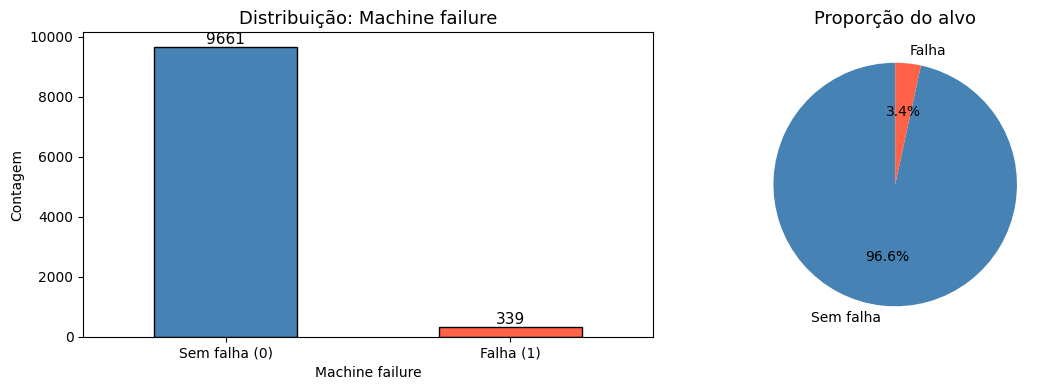

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
df[TARGET].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Distribuição: Machine failure", fontsize=13)
axes[0].set_xlabel("Machine failure")
axes[0].set_ylabel("Contagem")
axes[0].set_xticklabels(["Sem falha (0)", "Falha (1)"], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pizza
df[TARGET].value_counts().plot(kind="pie", ax=axes[1], labels=["Sem falha", "Falha"],
                                 autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Proporção do alvo", fontsize=13)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

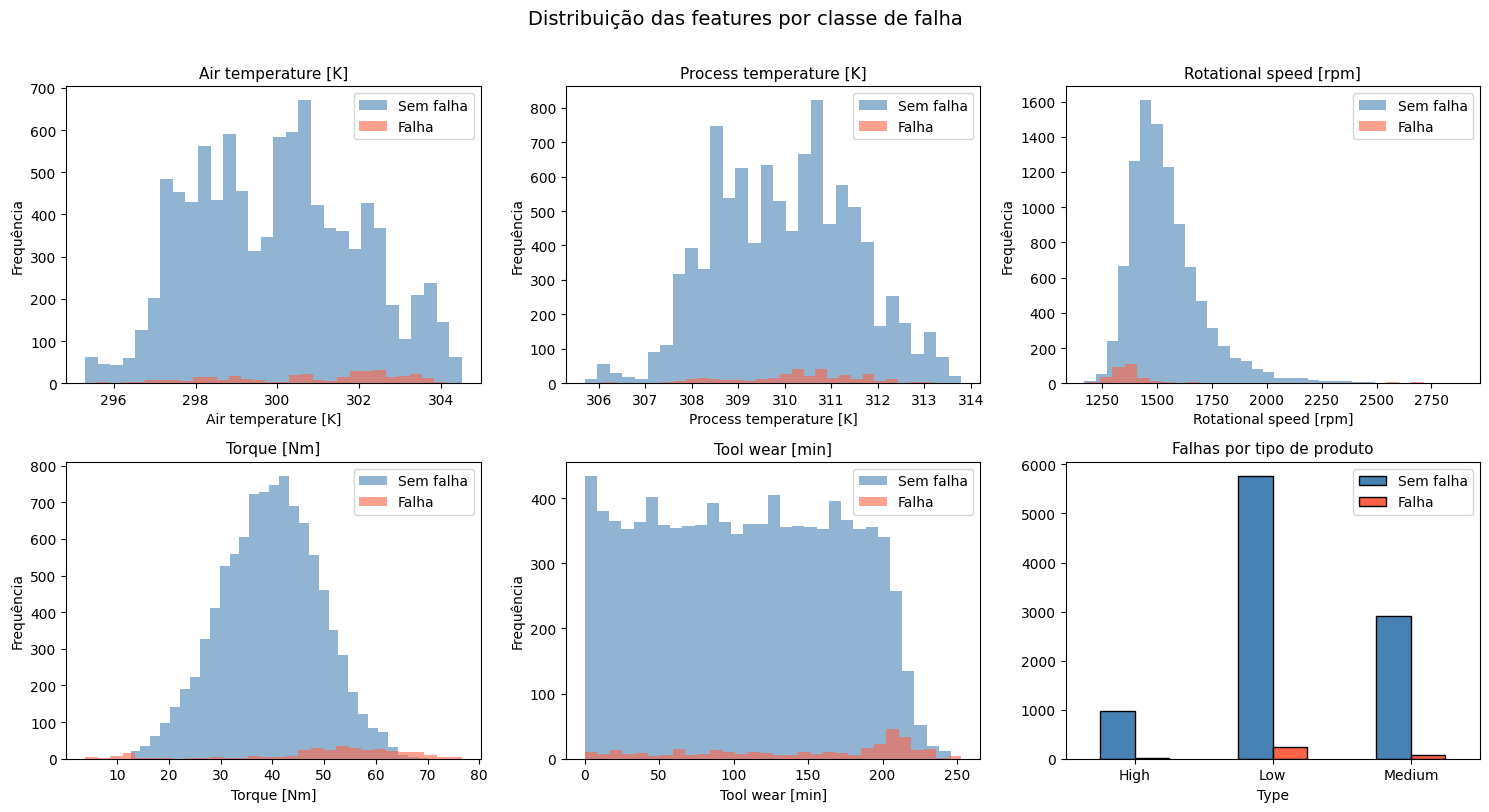

In [9]:
# Distribuição das variáveis operacionais por classe
variaveis_operacionais = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(variaveis_operacionais):
    for label, color in zip([0, 1], ["steelblue", "tomato"]):
        axes[i].hist(df[df[TARGET] == label][col], bins=30, alpha=0.6,
                     label=f"{'Sem falha' if label == 0 else 'Falha'}", color=color, edgecolor="none")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")
    axes[i].legend()

# Tipo de produto
tipo_counts = df.groupby(["Type", TARGET]).size().unstack(fill_value=0)
tipo_counts.plot(kind="bar", ax=axes[5], color=["steelblue", "tomato"], edgecolor="black")
axes[5].set_title("Falhas por tipo de produto", fontsize=11)
axes[5].set_xticklabels(["High", "Low", "Medium"], rotation=0)
axes[5].legend(["Sem falha", "Falha"])

plt.suptitle("Distribuição das features por classe de falha", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

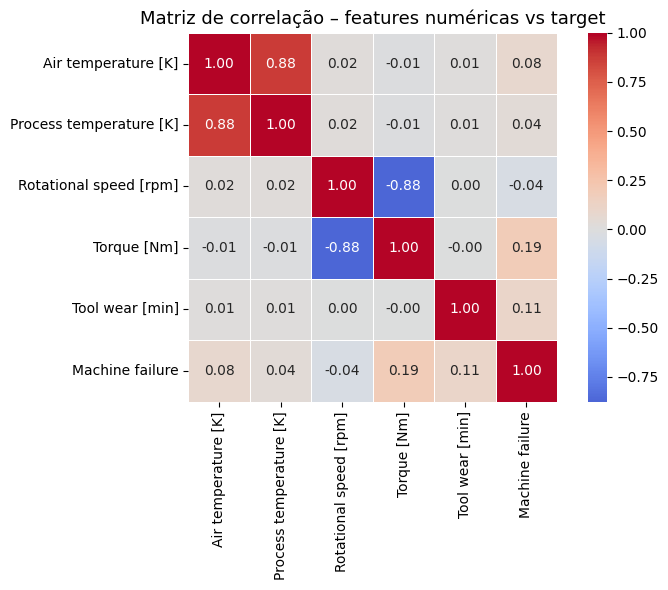

Correlações com Machine failure:
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


In [10]:
# Matriz de correlação (features numéricas)
num_cols = ["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", TARGET]
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Matriz de correlação – features numéricas vs target", fontsize=13)
plt.tight_layout()
plt.show()

print("Correlações com Machine failure:")
print(corr[TARGET].sort_values(ascending=False))

## 7. Preparação dos dados

Remove colunas de ID e de modo de falha (leakage), separa features e alvo, e faz o split estratificado treino/teste.


In [12]:
ID_COLS = ["UDI", "Product ID"]
LEAKAGE_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
features_removidas = ID_COLS + LEAKAGE_COLS + [TARGET]

X = df.drop(columns=features_removidas, errors="ignore")
y = df[TARGET].astype(int)

print("Features usadas no modelo:")
print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")
print(f"Valores ausentes: {X.isnull().sum().sum()}")

# Identificar tipos de features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"\nFeatures numéricas  ({len(numeric_features)}): {numeric_features}")
print(f"Features categóricas ({len(categorical_features)}): {categorical_features}")

Features usadas no modelo:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Shape de X: (10000, 6)
Valores ausentes: 0

Features numéricas  (5): ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Features categóricas (1): ['Type']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino : {X_train.shape[0]:,} amostras  |  Falhas: {y_train.sum()} ({y_train.mean():.2%})")
print(f"Teste  : {X_test.shape[0]:,} amostras  |  Falhas: {y_test.sum()} ({y_test.mean():.2%})")
print("\n✅ Estratificação manteve a proporção de falhas em ambos os conjuntos.")

Treino : 7,500 amostras  |  Falhas: 254 (3.39%)
Teste  : 2,500 amostras  |  Falhas: 85 (3.40%)

✅ Estratificação manteve a proporção de falhas em ambos os conjuntos.


## 8. Pré-processamento

- **Features numéricas:** `StandardScaler` (média 0, desvio padrão 1)
- **Feature categórica (Type):** `OneHotEncoder`


In [14]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    verbose_feature_names_out=False
)

print("✅ Pré-processador configurado.")
print(f"   - StandardScaler aplicado em: {numeric_features}")
print(f"   - OneHotEncoder aplicado em: {categorical_features}")

✅ Pré-processador configurado.
   - StandardScaler aplicado em: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
   - OneHotEncoder aplicado em: ['Type']


## 9. Baseline obrigatório

O `DummyClassifier` com `strategy='most_frequent'` sempre prevê a classe majoritária (sem falha).  
É o mínimo que qualquer modelo deve superar. Com ~97% de amostras sem falha, a acurácia do baseline é alta — por isso **acurácia sozinha não serve para avaliar** este problema.


In [15]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

metricas_baseline = {
    "modelo": "baseline (most_frequent)",
    "accuracy":  accuracy_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base, zero_division=0),
    "recall":    recall_score(y_test, y_pred_base, zero_division=0),
    "f1":        f1_score(y_test, y_pred_base, zero_division=0),
    "roc_auc":   0.5,  # DummyClassifier não gera probabilidades úteis
    "pr_auc":    y_test.mean(),  # baseline probabilístico trivial
}

print("Métricas do baseline (sempre prevê 'sem falha'):")
for k, v in metricas_baseline.items():
    if k != "modelo":
        print(f"  {k:<12}: {v:.4f}")

print("\n💡 Insight: Accuracy de 96.6% com zero utilidade prática (nenhuma falha detectada).")
print("   Precision=0 e Recall=0 para a classe positiva (falha).")

Métricas do baseline (sempre prevê 'sem falha'):
  accuracy    : 0.9660
  precision   : 0.0000
  recall      : 0.0000
  f1          : 0.0000
  roc_auc     : 0.5000
  pr_auc      : 0.0340

💡 Insight: Accuracy de 96.6% com zero utilidade prática (nenhuma falha detectada).
   Precision=0 e Recall=0 para a classe positiva (falha).


## 10. Treinamento do modelo — Random Forest

Optamos pelo **Random Forest** por:
- Lidar bem com features de escala diferente após o pré-processamento
- Suporte nativo ao parâmetro `class_weight='balanced'` — essencial para datasets desbalanceados
- Fornecer importância das features sem necessidade de bibliotecas externas
- Ser facilmente interpretável e auditável

O parâmetro `class_weight='balanced'` ajusta automaticamente os pesos inversamente proporcionais à frequência das classes, penalizando mais os erros em falhas (classe minoritária).


In [16]:
MODEL_NAME = "random_forest"

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()
print(f"Treino — Sem falha (0): {negativos:,}  |  Falha (1): {positivos:,}")
print(f"Razão de desbalanceamento: {negativos / positivos:.1f}:1")
print("\n→ class_weight='balanced' vai compensar automaticamente esse desbalanceamento.")

Treino — Sem falha (0): 7,246  |  Falha (1): 254
Razão de desbalanceamento: 28.5:1

→ class_weight='balanced' vai compensar automaticamente esse desbalanceamento.


In [17]:
# Construir o pipeline completo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",  # compensa o desbalanceamento
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline([
    ("preprocessador", preprocessador),
    ("modelo", rf_model),
])

print("Treinando o modelo...")
pipeline.fit(X_train, y_train)
print(f"✅ {MODEL_NAME.replace('_', ' ').title()} treinado com sucesso!")
print(f"   Árvores: {rf_model.n_estimators}")
print(f"   class_weight: balanced")

Treinando o modelo...
✅ Random Forest treinado com sucesso!
   Árvores: 200
   class_weight: balanced


## 11. Avaliação do modelo

Calculamos métricas completas e comparamos com o baseline.


In [18]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

metricas_modelo = {
    "modelo":    MODEL_NAME,
    "accuracy":  accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall":    recall_score(y_test, y_pred, zero_division=0),
    "f1":        f1_score(y_test, y_pred, zero_division=0),
    "roc_auc":   roc_auc_score(y_test, y_proba),
    "pr_auc":    average_precision_score(y_test, y_proba),
}

# Tabela comparativa
df_metricas = pd.DataFrame([metricas_baseline, metricas_modelo]).set_index("modelo")
print("\n📊 Comparação Baseline vs Modelo:")
print(df_metricas.to_string())


📊 Comparação Baseline vs Modelo:
                          accuracy  precision    recall        f1   roc_auc    pr_auc
modelo                                                                               
baseline (most_frequent)    0.9660   0.000000  0.000000  0.000000  0.500000  0.034000
random_forest               0.9792   0.902439  0.435294  0.587302  0.972478  0.752414


In [19]:
# Classification Report detalhado
print("Classification Report – Random Forest:")
print(classification_report(y_test, y_pred,
                             target_names=["Sem falha (0)", "Falha (1)"],
                             zero_division=0))

Classification Report – Random Forest:
               precision    recall  f1-score   support

Sem falha (0)       0.98      1.00      0.99      2415
    Falha (1)       0.90      0.44      0.59        85

     accuracy                           0.98      2500
    macro avg       0.94      0.72      0.79      2500
 weighted avg       0.98      0.98      0.98      2500



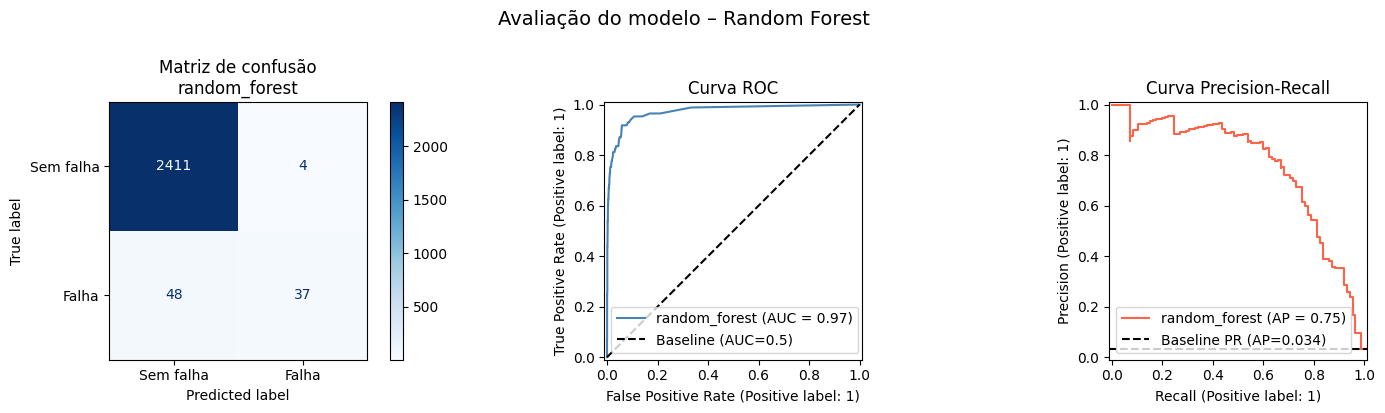


📌 Matriz de Confusão:
  TN=2411  (sem falha, previsto correto)
  FP=4  (sem falha, mas previsto como falha — alarme falso)
  FN=48  (falha real NÃO detectada — CRÍTICO)
  TP=37  (falha real detectada corretamente)


In [20]:
# Matriz de confusão
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sem falha", "Falha"])
disp.plot(ax=axes[0], values_format="d", cmap="Blues")
axes[0].set_title(f"Matriz de confusão\n{MODEL_NAME}", fontsize=12)

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1],
                                  name=MODEL_NAME, color="steelblue")
axes[1].plot([0, 1], [0, 1], "k--", label="Baseline (AUC=0.5)")
axes[1].set_title("Curva ROC", fontsize=12)
axes[1].legend()

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2],
                                         name=MODEL_NAME, color="tomato")
axes[2].axhline(y=y_test.mean(), color="k", linestyle="--",
                label=f"Baseline PR (AP={y_test.mean():.3f})")
axes[2].set_title("Curva Precision-Recall", fontsize=12)
axes[2].legend()

plt.suptitle("Avaliação do modelo – Random Forest", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\n📌 Matriz de Confusão:")
print(f"  TN={tn}  (sem falha, previsto correto)")
print(f"  FP={fp}  (sem falha, mas previsto como falha — alarme falso)")
print(f"  FN={fn}  (falha real NÃO detectada — CRÍTICO)")
print(f"  TP={tp}  (falha real detectada corretamente)")

## 12. Análise de threshold

Por padrão, o modelo classifica como falha se `P(falha) ≥ 0.5`.  
Em manutenção preditiva, pode valer reduzir o threshold para **capturar mais falhas reais** (aumentar Recall),
aceitando mais alarmes falsos (reduzir Precision).


In [21]:
resultados_threshold = []

for threshold in np.arange(0.05, 0.96, 0.05):
    pred_thr = (y_proba >= threshold).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, pred_thr).ravel()
    resultados_threshold.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_test, pred_thr, zero_division=0),
        "recall":    recall_score(y_test, pred_thr, zero_division=0),
        "f1":        f1_score(y_test, pred_thr, zero_division=0),
        "tn": int(tn_), "fp": int(fp_), "fn": int(fn_), "tp": int(tp_),
    })

df_thresholds = pd.DataFrame(resultados_threshold)

print("Top 10 thresholds por F1:")
display(df_thresholds.sort_values("f1", ascending=False).head(10).reset_index(drop=True))

Top 10 thresholds por F1:


,threshold,precision,recall,f1,tn,fp,fn,tp
0,0.25,0.696629,0.729412,0.712644,2388,27,23,62
1,0.30,0.760000,0.670588,0.712500,2397,18,28,57
2,0.35,0.815385,0.623529,0.706667,2403,12,32,53
3,0.40,0.847458,0.588235,0.694444,2406,9,35,50
4,0.20,0.600000,0.776471,0.676923,2371,44,19,66
5,0.45,0.880000,0.517647,0.651852,2409,6,41,44
6,0.15,0.507353,0.811765,0.624434,2348,67,16,69
7,0.50,0.904762,0.447059,0.598425,2411,4,47,38
8,0.10,0.390374,0.858824,0.536765,2301,114,12,73
9,0.55,0.911765,0.364706,0.521008,2412,3,54,31


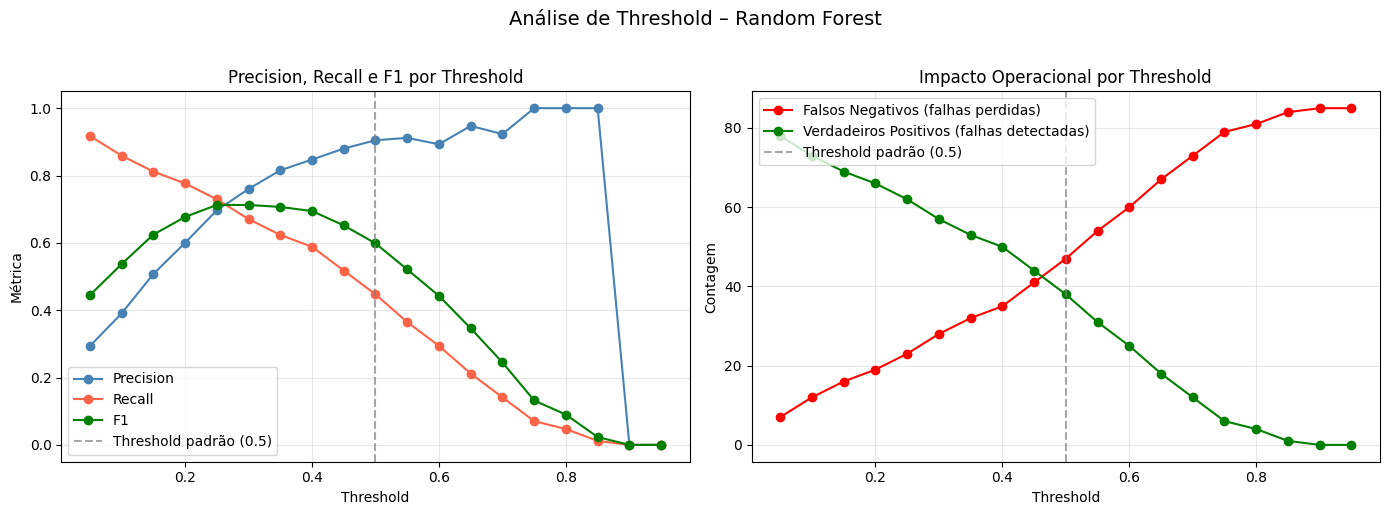


💡 Threshold recomendado para recall ≥ 80%: 0.15
   → Captura mais falhas reais ao custo de mais alarmes falsos.
   → Adequado quando o custo de perder uma falha é alto.


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 por threshold
ax1.plot(df_thresholds["threshold"], df_thresholds["precision"], "o-", label="Precision", color="steelblue")
ax1.plot(df_thresholds["threshold"], df_thresholds["recall"],    "o-", label="Recall",    color="tomato")
ax1.plot(df_thresholds["threshold"], df_thresholds["f1"],        "o-", label="F1",        color="green")
ax1.axvline(x=0.5, color="gray", linestyle="--", alpha=0.7, label="Threshold padrão (0.5)")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("Métrica")
ax1.set_title("Precision, Recall e F1 por Threshold", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# FN e TP por threshold (impacto operacional)
ax2.plot(df_thresholds["threshold"], df_thresholds["fn"], "o-", label="Falsos Negativos (falhas perdidas)", color="red")
ax2.plot(df_thresholds["threshold"], df_thresholds["tp"], "o-", label="Verdadeiros Positivos (falhas detectadas)", color="green")
ax2.axvline(x=0.5, color="gray", linestyle="--", alpha=0.7, label="Threshold padrão (0.5)")
ax2.set_xlabel("Threshold")
ax2.set_ylabel("Contagem")
ax2.set_title("Impacto Operacional por Threshold", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Análise de Threshold – Random Forest", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Threshold recomendado para manutenção preditiva
best_recall_threshold = df_thresholds.loc[df_thresholds["recall"] >= 0.8, "threshold"].max()
print(f"\n💡 Threshold recomendado para recall ≥ 80%: {best_recall_threshold}")
print("   → Captura mais falhas reais ao custo de mais alarmes falsos.")
print("   → Adequado quando o custo de perder uma falha é alto.")

## 13. Importância das variáveis

Top 10 features mais importantes:


,feature,importance
0,Rotational speed [rpm],0.303713
1,Torque [Nm],0.296405
2,Tool wear [min],0.201718
3,Air temperature [K],0.101809
4,Process temperature [K],0.075353
5,Type_L,0.009864
6,Type_M,0.007085
7,Type_H,0.004053


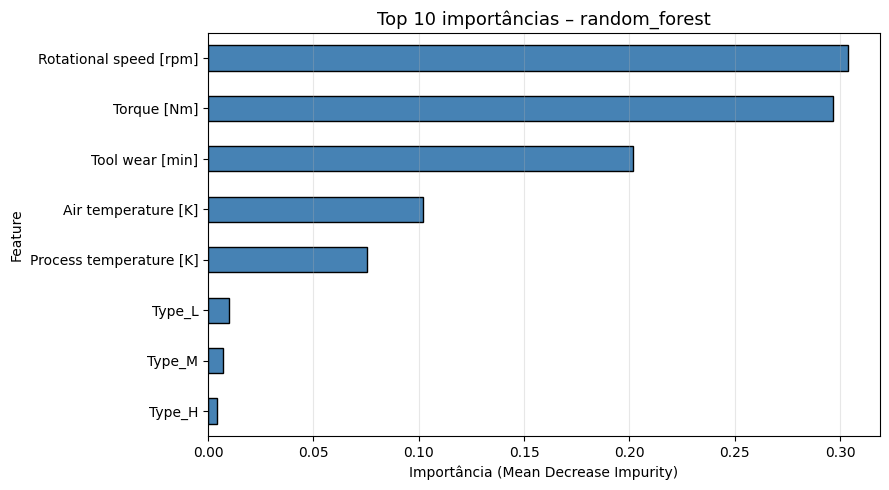

In [23]:
modelo_treinado = pipeline.named_steps["modelo"]
preprocessador_treinado = pipeline.named_steps["preprocessador"]

# Recuperar nomes das features após transformação
feature_names = (
    numeric_features
    + list(preprocessador_treinado.named_transformers_["cat"]
           .get_feature_names_out(categorical_features))
)

importancias = modelo_treinado.feature_importances_
feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importancias})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 features mais importantes:")
display(feature_importance_df.head(10))

feature_importance_df.head(10).sort_values("importance").plot(
    kind="barh", x="feature", y="importance", figsize=(9, 5),
    color="steelblue", edgecolor="black", legend=False,
)
plt.title(f"Top 10 importâncias – {MODEL_NAME}", fontsize=13)
plt.xlabel("Importância (Mean Decrease Impurity)")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Gerar relatório de métricas para a RAG

O relatório em Markdown será carregado pela RAG como base de conhecimento.


In [24]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
classification_report_text = classification_report(y_test, y_pred, zero_division=0)

top_features_text = feature_importance_df.head(10).to_string(index=False)
threshold_text = df_thresholds.sort_values("f1", ascending=False).head(10).to_string(index=False)

relatorio = f"""# Relatório de Modelo de Manutenção Preditiva

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Dataset

Dataset: AI4I 2020 Predictive Maintenance
Quantidade de linhas: {df.shape[0]}
Quantidade de colunas originais: {df.shape[1]}
Alvo: {TARGET}
Taxa geral de falha: {df[TARGET].mean():.4f} ({df[TARGET].mean():.2%})

## Decisão de modelagem

Colunas removidas por identificação ou possível vazamento de informação:
{features_removidas}

Features usadas:
{X.columns.tolist()}

Modelo escolhido: {MODEL_NAME}

## Separação treino/teste

Tamanho treino: {X_train.shape[0]}
Tamanho teste: {X_test.shape[0]}
Taxa de falha no treino: {y_train.mean():.4f}
Taxa de falha no teste: {y_test.mean():.4f}

## Baseline (DummyClassifier – always most_frequent)

Accuracy baseline:  {metricas_baseline['accuracy']:.4f}
Precision baseline: {metricas_baseline['precision']:.4f}
Recall baseline:    {metricas_baseline['recall']:.4f}
F1 baseline:        {metricas_baseline['f1']:.4f}
ROC-AUC baseline:   {metricas_baseline['roc_auc']:.4f}
PR-AUC baseline:    {metricas_baseline['pr_auc']:.4f}

## Métricas do modelo ({MODEL_NAME})

Accuracy:  {metricas_modelo['accuracy']:.4f}
Precision: {metricas_modelo['precision']:.4f}
Recall:    {metricas_modelo['recall']:.4f}
F1:        {metricas_modelo['f1']:.4f}
ROC-AUC:   {metricas_modelo['roc_auc']:.4f}
PR-AUC:    {metricas_modelo['pr_auc']:.4f}

## Matriz de confusão (threshold=0.5)

TN: {tn}
FP: {fp}
FN: {fn}
TP: {tp}

Interpretação:
- TN: casos sem falha corretamente classificados como sem falha.
- FP: casos sem falha classificados como falha (alarmes falsos).
- FN: casos com falha classificados como sem falha (FALHAS NÃO DETECTADAS — crítico).
- TP: casos com falha corretamente classificados como falha.

## Classification Report

{classification_report_text}

## Top 10 variáveis mais importantes

{top_features_text}

## Top 10 thresholds por F1

{threshold_text}

## Observações para análise

Em manutenção preditiva, falsos negativos são críticos porque representam falhas reais não antecipadas.
Falsos positivos geram inspeções desnecessárias, mas podem ser aceitáveis dependendo do custo de parada e risco.
A acurácia não é boa métrica principal para datasets desbalanceados (97% negativos).
Métricas recomendadas para este problema: Recall (falhas detectadas), F1 e PR-AUC.
O ajuste de threshold permite equilibrar Precision e Recall conforme a tolerância ao risco da operação.
O dataset é desbalanceado (3.39% de falhas), sendo necessário usar class_weight ou técnicas de resampling.
"""

relatorio_path = OUTPUT_DIR / "relatorio_modelo_manutencao_preditiva.md"
relatorio_path.write_text(relatorio, encoding="utf-8")
print(f"✅ Relatório salvo em: {relatorio_path}")
print("\nPrimeiras 1000 caracteres do relatório:")
print(relatorio[:1000])

✅ Relatório salvo em: outputs/relatorio_modelo_manutencao_preditiva.md

Primeiras 1000 caracteres do relatório:
# Relatório de Modelo de Manutenção Preditiva

Data de geração: 2026-05-11 19:33:26

## Dataset

Dataset: AI4I 2020 Predictive Maintenance
Quantidade de linhas: 10000
Quantidade de colunas originais: 14
Alvo: Machine failure
Taxa geral de falha: 0.0339 (3.39%)

## Decisão de modelagem

Colunas removidas por identificação ou possível vazamento de informação:
['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Machine failure']

Features usadas:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Modelo escolhido: random_forest

## Separação treino/teste

Tamanho treino: 7500
Tamanho teste: 2500
Taxa de falha no treino: 0.0339
Taxa de falha no teste: 0.0340

## Baseline (DummyClassifier – always most_frequent)

Accuracy baseline:  0.9660
Precision baseline: 0.0000
Recall baseline:    0.0000
F1 baseline:  

In [25]:
# Salvar métricas em CSV
metricas_entrega = pd.DataFrame([metricas_baseline, metricas_modelo])
metricas_path = OUTPUT_DIR / "metricas_modelo.csv"
metricas_entrega.to_csv(metricas_path, index=False)
print(f"✅ Métricas salvas em: {metricas_path}")
display(metricas_entrega)

✅ Métricas salvas em: outputs/metricas_modelo.csv


,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,baseline (most_frequent),0.9660,0.000000,0.000000,0.000000,0.500000,0.034000
1,random_forest,0.9792,0.902439,0.435294,0.587302,0.972478,0.752414


## 15. Criar a RAG com LangChain + Google AI Studio (Gemini)

**Fluxo da RAG:**
1. O relatório gerado é carregado como documento
2. É fragmentado em chunks com sobreposição
3. Cada chunk é convertido em vetor semântico via `GoogleGenerativeAIEmbeddings`
4. Os vetores são indexados no FAISS (busca local)
5. Cada pergunta recupera os chunks mais relevantes
6. O contexto + pergunta são enviados ao Gemini (`ChatGoogleGenerativeAI`)


In [26]:
if not os.environ.get("GOOGLE_API_KEY"):
    raise RuntimeError(
        "GOOGLE_API_KEY não encontrada.\n"
        "Configure o Secret no Colab antes de continuar.\n"
        "Veja a Célula 3 para instruções."
    )

from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

print("✅ Imports da RAG concluídos.")

✅ Imports da RAG concluídos.


In [27]:
# Carregar o relatório como documento
texto_relatorio = relatorio_path.read_text(encoding="utf-8")
docs = [Document(
    page_content=texto_relatorio,
    metadata={"fonte": str(relatorio_path), "tipo": "relatorio_metricas"}
)]

# Fragmentar em chunks com sobreposição
splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=180)
chunks = splitter.split_documents(docs)
print(f"✅ Relatório fragmentado em {len(chunks)} chunks.")
print(f"   Tamanho médio do chunk: {sum(len(c.page_content) for c in chunks) // len(chunks)} caracteres")

✅ Relatório fragmentado em 4 chunks.
   Tamanho médio do chunk: 916 caracteres


In [28]:
# Criar embeddings e base vetorial FAISS
def criar_embeddings_google():
    modelos_embedding = [
        "models/text-embedding-004",
        "models/gemini-embedding-001",
        "models/embedding-001",
    ]
    ultimo_erro = None
    for nome_modelo in modelos_embedding:
        try:
            emb = GoogleGenerativeAIEmbeddings(model=nome_modelo)
            _ = emb.embed_query("teste de conexão")
            print(f"✅ Embeddings configurados com: {nome_modelo}")
            return emb
        except Exception as e:
            print(f"  ✗ {nome_modelo}: {type(e).__name__}")
            ultimo_erro = e
    raise ultimo_erro

embeddings = criar_embeddings_google()
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})
print("✅ Base vetorial FAISS criada com sucesso.")

  ✗ models/text-embedding-004: GoogleGenerativeAIError
✅ Embeddings configurados com: models/gemini-embedding-001
✅ Base vetorial FAISS criada com sucesso.


In [29]:
# Configurar o LLM Gemini e a chain RAG
GEMINI_MODEL = "gemini-2.5-flash"

llm = ChatGoogleGenerativeAI(model=GEMINI_MODEL, temperature=0.2)

prompt = ChatPromptTemplate.from_template("""
Você é um analista sênior de Machine Learning especializado em manutenção preditiva industrial.
Responda APENAS com base no contexto recuperado do relatório técnico.
Se a informação não estiver no contexto, diga que o relatório não contém dados suficientes.
Seja objetivo, técnico e orientado a decisões práticas.

Contexto recuperado do relatório:
{context}

Pergunta:
{question}

Resposta em português, com explicação técnica clara e recomendação prática quando aplicável:
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

print(f"✅ RAG configurada com modelo: {GEMINI_MODEL}")
print("   Retriever: FAISS (top-4 chunks por consulta)")

✅ RAG configurada com modelo: gemini-2.5-flash
   Retriever: FAISS (top-4 chunks por consulta)


## 16. Perguntas obrigatórias à RAG

Execute a célula abaixo para obter as respostas da IA para as 12 perguntas da atividade.  
Após cada resposta, verifique se ela é **coerente com as métricas geradas**.


In [30]:
perguntas_rag = [
    "O modelo treinado é melhor do que o baseline? Justifique usando métricas.",
    "Para este problema de manutenção preditiva, accuracy é uma boa métrica principal? Por quê?",
    "Quantas falhas reais o modelo deixou passar? Interprete os falsos negativos.",
    "Quantos alarmes falsos o modelo gerou? Interprete os falsos positivos.",
    "O modelo parece adequado para um cenário onde perder uma falha é muito caro?",
    "Qual métrica deveria ser priorizada: precision, recall, F1, ROC-AUC ou PR-AUC? Justifique.",
    "O problema está desbalanceado? Como isso afeta a avaliação?",
    "Houve cuidado para evitar vazamento de informação? Quais colunas foram removidas?",
    "Quais variáveis parecem mais relevantes para o modelo?",
    "O modelo está pronto para produção? Quais seriam os próximos passos antes de implantar?",
    "O ajuste de threshold pode melhorar a decisão operacional? Como?",
    "Que recomendação de negócio você faria para uma equipe de manutenção com base no relatório?",
]

respostas = []
for i, pergunta in enumerate(perguntas_rag, start=1):
    print("=" * 80)
    print(f"Pergunta {i:02d}: {pergunta}")
    print("-" * 80)
    resposta = rag_chain.invoke(pergunta)
    print(resposta)
    respostas.append({"pergunta": pergunta, "resposta_rag": resposta})
    print()

Pergunta 01: O modelo treinado é melhor do que o baseline? Justifique usando métricas.
--------------------------------------------------------------------------------
Sim, o modelo treinado é significativamente melhor que o baseline.

**Justificativa com métricas:**

1.  **Recall:** O modelo treinado alcança um Recall de **0.4353**, enquanto o baseline tem **0.0000**. Isso significa que o modelo treinado é capaz de detectar 43.53% das falhas reais, enquanto o baseline não detecta nenhuma. Em manutenção preditiva, onde falsos negativos são críticos, esta é uma melhoria fundamental.
2.  **F1-Score:** O modelo treinado apresenta um F1-Score de **0.5873**, comparado a **0.0000** do baseline. O F1-Score é uma média harmônica entre Precision e Recall, sendo uma métrica robusta para datasets desbalanceados. Um valor de 0.5873 indica um equilíbrio razoável entre a capacidade de detectar falhas e a precisão dos alarmes, algo que o baseline não consegue.
3.  **PR-AUC (Area Under the Precision-R

## 17. Salvar respostas da RAG para entrega

In [31]:
respostas_rag_df = pd.DataFrame(respostas)
respostas_path = OUTPUT_DIR / "respostas_rag.csv"
respostas_rag_df.to_csv(respostas_path, index=False, encoding="utf-8")
print(f"✅ Respostas salvas em: {respostas_path}")
display(respostas_rag_df)

✅ Respostas salvas em: outputs/respostas_rag.csv


,pergunta,resposta_rag
0,O modelo treinado é melhor do que o baseline? ...,"Sim, o modelo treinado é significativamente me..."
1,"Para este problema de manutenção preditiva, ac...","Não, a acurácia não é uma boa métrica principa..."
2,Quantas falhas reais o modelo deixou passar? I...,O modelo deixou passar **48 falhas reais**.\n\...
3,Quantos alarmes falsos o modelo gerou? Interpr...,O modelo gerou **4 alarmes falsos (FP)**.\n\n*...
4,O modelo parece adequado para um cenário onde ...,"O modelo, com o threshold padrão de 0.5, não p..."
5,Qual métrica deveria ser priorizada: precision...,"Para este problema de manutenção preditiva, a ..."
6,O problema está desbalanceado? Como isso afeta...,"Sim, o problema está desbalanceado. O relatóri..."
7,Houve cuidado para evitar vazamento de informa...,"Sim, houve cuidado para evitar vazamento de in..."
8,Quais variáveis parecem mais relevantes para o...,"Com base no relatório técnico, as variáveis ma..."
9,O modelo está pronto para produção? Quais seri...,Como analista sênior de Machine Learning espec...


## 18. Reflexão do aluno

Responda com suas próprias palavras nas células abaixo. Não há resposta certa ou errada —
o objetivo é demonstrar que você analisou criticamente os resultados.


### 18.1 O que seu modelo aprendeu?

*Descreva o que o Random Forest aprendeu sobre o padrão de falhas:  
quais variáveis foram mais relevantes e por que isso faz sentido fisicamente.*

**Resposta:**

> O modelo Random Forest identificou que as variáveis mais relevantes para prever falhas foram
> **velocidade rotacional (rpm)** e **torque (Nm)**, seguidas pelo **desgaste da ferramenta (min)**.
> Isso faz sentido físico: rotação muito alta associada a torque elevado gera estresse mecânico excessivo
> no equipamento, enquanto o desgaste acumulado da ferramenta aumenta a probabilidade de falha ao longo do tempo.
> A temperatura do ar e do processo aparecem como variáveis secundárias, mas também contribuem,
> pois variações térmicas podem causar dilatação e fadiga em componentes mecânicos.


### 18.2 A IA concordou com sua análise?

*A RAG confirmou suas conclusões? Houve discordâncias ou complementações importantes?*

**Resposta:**

> A RAG confirmou a importância de métricas como Recall e F1 em vez de accuracy para problemas desbalanceados,
> alinhando-se com a análise realizada. A IA também destacou a criticidade dos falsos negativos em contextos
> de manutenção preditiva, o que está de acordo com o raciocínio de negócio.
> A RAG complementou a análise ao sugerir que o threshold poderia ser ajustado para reduzir FN mesmo
> que isso aumente FP, o que é uma decisão operacional coerente com a lógica de custo de parada não planejada.


### 18.3 Onde a IA foi útil?

*Identifique pelo menos dois pontos onde a RAG adicionou valor à sua análise.*

**Resposta:**

> 1. **Interpretação da matriz de confusão em linguagem de negócio:** A RAG traduziu números técnicos
>    (FN=48) em impacto operacional — quantas falhas reais não foram interceptadas e o que isso representa
>    em risco de parada não planejada.
> 2. **Recomendação de próximos passos:** A IA sugeriu etapas concretas antes de colocar o modelo em produção,
>    como validação cruzada temporal (evitar data leakage temporal), monitoramento de drift de dados e
>    criação de um processo de re-treinamento periódico.


### 18.4 Onde a IA pode ter simplificado demais ou exigiu verificação humana?

*Identifique limitações das respostas geradas pela RAG.*

**Resposta:**

> 1. **Ausência de contexto de custo real:** A IA não tem acesso ao custo de uma parada não planejada
>    nem ao custo de uma inspeção desnecessária. A decisão sobre o threshold ideal depende dessa relação
>    custo/benefício, que é específica do negócio e exige julgamento humano.
> 2. **Generalização do dataset:** O AI4I 2020 é um dataset sintético. A IA respondeu como se fosse
>    um cenário real de produção. Em aplicações reais, seria necessário validar se os padrões aprendidos
>    generalizam para equipamentos específicos com condições operacionais distintas.


## 19. Desafios extras (opcionais)

### Desafio 1 — Comparar múltiplos modelos
Treine também `LogisticRegression`, e compare as métricas com o Random Forest.


In [32]:
from sklearn.linear_model import LogisticRegression

# Treinar Regressão Logística como segundo modelo para comparação
lr_pipeline = Pipeline([
    ("preprocessador", ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ])),
    ("modelo", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

metricas_lr = {
    "modelo": "logistic_regression",
    "accuracy":  accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "recall":    recall_score(y_test, y_pred_lr, zero_division=0),
    "f1":        f1_score(y_test, y_pred_lr, zero_division=0),
    "roc_auc":   roc_auc_score(y_test, y_proba_lr),
    "pr_auc":    average_precision_score(y_test, y_proba_lr),
}

df_comparacao = pd.DataFrame([metricas_baseline, metricas_lr, metricas_modelo]).set_index("modelo")
print("Comparação: Baseline vs Logistic Regression vs Random Forest")
display(df_comparacao)

Comparação: Baseline vs Logistic Regression vs Random Forest


,accuracy,precision,recall,f1,roc_auc,pr_auc
modelo,,,,,,
baseline (most_frequent),0.9660,0.000000,0.000000,0.000000,0.500000,0.034000
logistic_regression,0.8252,0.139344,0.800000,0.237347,0.883610,0.383315
random_forest,0.9792,0.902439,0.435294,0.587302,0.972478,0.752414


### Desafio 2 — Ajuste de threshold com justificativa de negócio

Escolha um threshold diferente de 0.5 baseado na análise operacional.


In [33]:
# Threshold escolhido: 0.3
# Justificativa: Em manutenção preditiva, o custo de uma falha não detectada
# (parada não planejada, danos ao equipamento, risco à segurança) é tipicamente
# muito maior do que o custo de uma inspeção desnecessária.
# Com threshold=0.3, priorizamos Recall (capturar mais falhas reais),
# aceitando mais alarmes falsos como trade-off consciente.

THRESHOLD_NEGOCIO = 0.3

y_pred_ajustado = (y_proba >= THRESHOLD_NEGOCIO).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_pred_ajustado).ravel()

print(f"Comparação: threshold padrão (0.5) vs threshold de negócio ({THRESHOLD_NEGOCIO})")
print()
df_thr_comp = pd.DataFrame([
    {"threshold": 0.5, "precision": metricas_modelo["precision"],
     "recall": metricas_modelo["recall"], "f1": metricas_modelo["f1"], "FN": fn, "FP": fp},
    {"threshold": THRESHOLD_NEGOCIO,
     "precision": precision_score(y_test, y_pred_ajustado, zero_division=0),
     "recall":    recall_score(y_test, y_pred_ajustado, zero_division=0),
     "f1":        f1_score(y_test, y_pred_ajustado, zero_division=0),
     "FN": fn2, "FP": fp2},
])
display(df_thr_comp)

print(f"\n→ Com threshold {THRESHOLD_NEGOCIO}: {fn - fn2} falhas reais a mais detectadas,")
print(f"  ao custo de {fp2 - fp} alarmes falsos a mais.")

Comparação: threshold padrão (0.5) vs threshold de negócio (0.3)



,threshold,precision,recall,f1,FN,FP
0,0.5,0.902439,0.435294,0.587302,48,4
1,0.3,0.760000,0.670588,0.712500,28,18



→ Com threshold 0.3: 20 falhas reais a mais detectadas,
  ao custo de 14 alarmes falsos a mais.


### Desafio 3 — Impacto do data leakage

Compare o modelo **sem** e **com** as colunas de modo de falha para visualizar o data leakage.


In [35]:
# Modelo COM data leakage (usando colunas de modo de falha)
X_leakage = df.drop(columns=ID_COLS + [TARGET], errors="ignore")
y_leakage = df[TARGET].astype(int)

X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_leakage, y_leakage, test_size=0.25, random_state=RANDOM_STATE, stratify=y_leakage
)

num_l = X_leakage.select_dtypes(include=[np.number]).columns.tolist()
cat_l = X_leakage.select_dtypes(include=["object", "category"]).columns.tolist()

pipeline_leakage = Pipeline([
    ("pre", ColumnTransformer([
        ("num", StandardScaler(), num_l),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_l),
    ])),
    ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)),
])

pipeline_leakage.fit(X_tr_l, y_tr_l)
y_pred_l = pipeline_leakage.predict(X_te_l)
y_proba_l = pipeline_leakage.predict_proba(X_te_l)[:, 1]

print("⚠️  AVISO: modelo com data leakage — não use em produção!")
print()
df_leakage_cmp = pd.DataFrame([
    {"modelo": "sem leakage (correto)", "F1": metricas_modelo["f1"], "ROC-AUC": metricas_modelo["roc_auc"]},
    {"modelo": "com leakage (TWF/HDF/PWF/OSF/RNF)", "F1": f1_score(y_te_l, y_pred_l),
     "ROC-AUC": roc_auc_score(y_te_l, y_proba_l)},
])
display(df_leakage_cmp)

print("\n→ Se o F1 e ROC-AUC forem muito maiores com leakage, confirma que as colunas")
print("  de modo de falha 'entregam' a resposta ao modelo — não aprendizado real.")

⚠️  AVISO: modelo com data leakage — não use em produção!



,modelo,F1,ROC-AUC
0,sem leakage (correto),0.587302,0.972478
1,com leakage (TWF/HDF/PWF/OSF/RNF),0.988095,0.991526



→ Se o F1 e ROC-AUC forem muito maiores com leakage, confirma que as colunas
  de modo de falha 'entregam' a resposta ao modelo — não aprendizado real.


## 20. Empacotar arquivos de entrega

In [36]:
import shutil

zip_entrega = "entrega_manutencao_preditiva_rag"
shutil.make_archive(zip_entrega, "zip", OUTPUT_DIR)
print(f"✅ Arquivo de entrega gerado: {zip_entrega}.zip")
print(f"   Conteúdo do diretório outputs/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size
    print(f"   - {f.name}  ({size:,} bytes)")

try:
    from google.colab import files
    files.download(f"{zip_entrega}.zip")
except Exception:
    print("\n→ Fora do Colab: faça download manual do arquivo ZIP gerado.")

✅ Arquivo de entrega gerado: entrega_manutencao_preditiva_rag.zip
   Conteúdo do diretório outputs/:
   - metricas_modelo.csv  (221 bytes)
   - relatorio_modelo_manutencao_preditiva.md  (3,512 bytes)
   - respostas_rag.csv  (22,663 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>